In [1]:
import pm4py
import pandas as pd
import os

parquet_path = os.path.join("data", "BPI_Challenge_2017.parquet")
df = pd.read_parquet(parquet_path)
log = pm4py.convert_to_event_log(df)

## Assignment 1

In [2]:
df = pm4py.convert_to_dataframe(log)
df.head()

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,NaN,NaN,None,NaN,None,NaN,NaN,NaN,Existing loan takeover,New credit,Application_652823628,20000.0
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,NaN,NaN,None,NaN,None,NaN,NaN,NaN,Existing loan takeover,New credit,Application_652823628,20000.0
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,NaN,NaN,None,NaN,None,NaN,NaN,NaN,Existing loan takeover,New credit,Application_652823628,20000.0
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,NaN,NaN,None,NaN,None,NaN,NaN,NaN,Existing loan takeover,New credit,Application_652823628,20000.0
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,NaN,NaN,None,NaN,None,NaN,NaN,NaN,Existing loan takeover,New credit,Application_652823628,20000.0


number of cases,number of events,number of process
variants, number of distinct case and event attribute
labels, mean and standard deviation of case length,
mean and standard deviation of case duration (in days,
minutes, and seconds), number of categorical event
attributes.

num_cases_application = merged_log['case:concept:name'].nunique()
num_cases_offer = offer_log['case:concept:name'].nunique()
print(f"Number of cases in application log: {num_cases_application}")
print(f"Number of cases in offer log: {num_cases_offer}"), 

Note: time shows slight deviation, needs review


In [3]:
import numpy as np

# Preparation: calculate case lengths and time differences
case_lengths = df.groupby('case:concept:name').size()
case_durations = pm4py.get_all_case_durations(log) # duration in seconds

# 1. Number of cases
num_cases = df['case:concept:name'].nunique()
print(f"Number of cases: {num_cases}")

# 2. Number of events
num_events = len(df)
print(f"Number of events: {num_events}")

# 3. Number of process variants
variants = pm4py.get_variants(log)
num_variants = len(variants)
print(f"Number of process variants: {num_variants}")

# 4. Number of distinct case and event attribute labels
# (count all column prefixes to distinguish case vs. event attributes)
num_case_attributes = len([col for col in df.columns if col.startswith('case:')])
num_event_attributes = len([col for col in df.columns if not col.startswith('case:')])
print(f"Number of distinct case attribute labels: {num_case_attributes}")
print(f"Number of distinct event attribute labels: {num_event_attributes}")

# 5. Mean and standard deviation of case length
print(f"Mean of case length: {case_lengths.mean():.2f}")
print(f"Standard deviation of case length: {case_lengths.std():.2f}")

# 6. Mean and standard deviation of case duration (Seconds)
mean_dur_sec = np.mean(case_durations)
std_dur_sec = np.std(case_durations)
print(f"Mean of case duration (seconds): {mean_dur_sec:.2f}")
print(f"Standard deviation of case duration (seconds): {std_dur_sec:.2f}")

# 7. Mean and standard deviation of case duration (Minutes)
print(f"Mean of case duration (minutes): {mean_dur_sec / 60:.2f}")
print(f"Standard deviation of case duration (minutes): {std_dur_sec / 60:.2f}")

# 8. Mean and standard deviation of case duration (Days)
print(f"Mean of case duration (days): {mean_dur_sec / 86400:.2f}")
print(f"Standard deviation of case duration (days): {std_dur_sec / 86400:.2f}")

# 9. Number of categorical event attributes
# Definierte Liste der fachlich relevanten kategorischen Event-Attribute
relevant_event_attributes = ['concept:name', 'lifecycle:transition']

# Filter to only attributes that actually exist in the DataFrame
num_cat_event_attrs = len([col for col in relevant_event_attributes if col in df.columns])

print(f"Number of categorical event attributes: {num_cat_event_attrs}")

Number of cases: 31509
Number of events: 1202267
Number of process variants: 15930
Number of distinct case attribute labels: 4
Number of distinct event attribute labels: 15
Mean of case length: 38.16
Standard deviation of case length: 16.72
Mean of case duration (seconds): 1892125.92
Standard deviation of case duration (seconds): 1137803.64
Mean of case duration (minutes): 31535.43
Standard deviation of case duration (minutes): 18963.39
Mean of case duration (days): 21.90
Standard deviation of case duration (days): 13.17
Number of categorical event attributes: 2


### Individual Statistics


### Case Outcome Distribution:

In [4]:
outcome_events = ['A_Pending', 'A_Cancelled', 'A_Denied']

# Use 'df' (DataFrame) instead of 'log' (EventLog)
case_outcomes = (
    df[df['concept:name'].isin(outcome_events)]
    .groupby('case:concept:name')['concept:name']
    .last()
    .reset_index()
)

case_outcomes.columns = ['case_id', 'outcome']
outcome_counts = case_outcomes['outcome'].value_counts()
print(outcome_counts)

outcome
A_Pending      17228
A_Cancelled    10431
A_Denied        3752
Name: count, dtype: int64


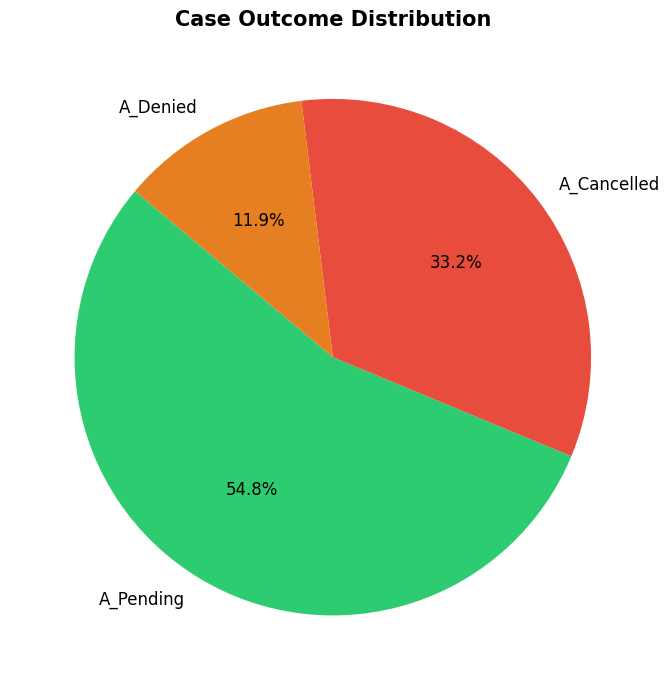

In [5]:
import matplotlib.pyplot as plt

colors = ['#2ecc71', '#e74c3c', '#e67e22']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    outcome_counts.values,
    labels=outcome_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)
ax.set_title('Case Outcome Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Offer Distribution per Case

In [6]:
all_cases = df['case:concept:name'].unique()

offer_counts = (
    df[df['concept:name'] == 'O_Create Offer']
    .groupby('case:concept:name')
    .size()
    .reindex(all_cases, fill_value=0)
)

offer_dist = offer_counts.value_counts().sort_index()

print("Number of offers per case:")
print(offer_dist)

Number of offers per case:
1     22950
2      6578
3      1348
4       443
5       126
6        30
7        16
8        13
9         3
10        2
Name: count, dtype: int64


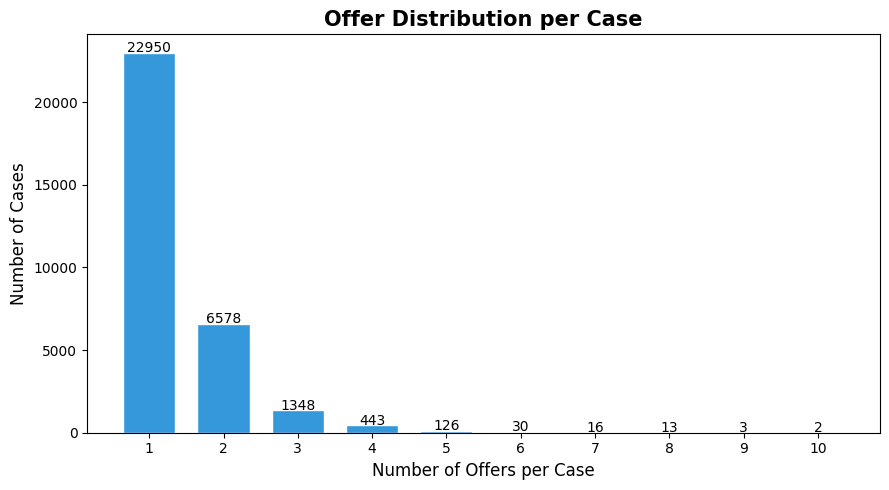

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    offer_dist.index,
    offer_dist.values,
    color='#3498db',
    edgecolor='white',
    width=0.7
)
ax.set_xlabel('Number of Offers per Case', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title('Offer Distribution per Case', fontsize=15, fontweight='bold')
ax.set_xticks(offer_dist.index)

for x, y in zip(offer_dist.index, offer_dist.values):
    ax.text(x, y + 50, str(y), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
case_attrs = [c for c in df.columns if c.startswith('case:')]
event_attrs = [c for c in df.columns if not c.startswith('case:')]
print(f"Case attribute labels: {len(case_attrs)} → {case_attrs}")
print(f"Event attribute labels: {len(event_attrs)} → {event_attrs}")

Case attribute labels: 4 → ['case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount']
Event attribute labels: 15 → ['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']
